In [16]:
%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

init_time = t.time()
from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF
print(f'Custom library import time: {(t.time() - init_time):.3} seconds')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Custom library import time: 4.58e-05 seconds


In [19]:
''' Preparing lens parameters '''
# Big planet parameters
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Small planet parameters
s2 = 0.8
alpha2 = 45
q2 = 1e-4

print(f'q1 = {q1}')
print(f'q2 = {q2}')
print(f's1 = {s1}')
print(f's2 = {s2}')
print(f'alpha1 = {alpha1}')
print(f'alpha2 = {alpha2}')

# Defining single lens attributes
single_lens_attributes = np.array([
    [0, 0, 1]
])

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Triple lens attributes
triple_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Rotation matrix for second planet
second_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
    [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
])

# Calculating translation of coordinate origin for each planet
q1 = triple_lens_attributes[1, 2]
q2 = triple_lens_attributes[2, 2]

delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)
print(f'Total offset: {total_offset}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Correcting triple lens attributes
triple_lens_attributes[:, :2] -= total_offset

# Map parameters
pixels = 1000
delta = 0.01

# ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(triple_lens_attributes)
# num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

# Using pre-calculated values
ang_width = 0.07680319680319682
thickness = 0.059738867403980045
y_minus = -0.970576558378381
y_plus = 1.030315425782361
# num_r = 779536
# num_theta = 194884

num_theta = 5000
num_r = 4*num_theta

print(f'Angular width: {ang_width}')
print(f'Thickness: {thickness}')
print(f'Annulus lower bound: {y_minus}')
print(f'Annulus upper bound: {y_plus}')
print(f'Number of rays in theta: {num_theta}')
print(f'Number of rays in r: {num_r}')

single_lens_parameters = {
    'pixels': pixels,
    'ang_width': ang_width,
    'thickness': thickness,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': single_lens_attributes.tolist(),
    'num_theta': num_theta,
    'num_r': num_r
}

binary_lens_parameters = single_lens_parameters.copy()
binary_lens_parameters.update({
    'lens_att': binary_lens_attributes.tolist()
})

triple_lens_parameters = single_lens_parameters.copy()
triple_lens_parameters.update({
    'lens_att': triple_lens_attributes.tolist()
})

print(f'Number of rays: {(num_r * num_theta):.4e}')
print('=========================================================')

q1 = 0.001
q2 = 0.0001
s1 = 0.8
s2 = 0.8
alpha1 = 0
alpha2 = 45
Total offset: [4.46151379e-04 3.13541498e-06]
Angular width: 0.07680319680319682
Thickness: 0.059738867403980045
Annulus lower bound: -0.970576558378381
Annulus upper bound: 1.030315425782361
Number of rays in theta: 5000
Number of rays in r: 20000
Number of rays: 1.0000e+08


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:04<00:00, 103.65it/s]


---------------------
Total time: 4.835 seconds
Plotting magnification map: 0.018 seconds


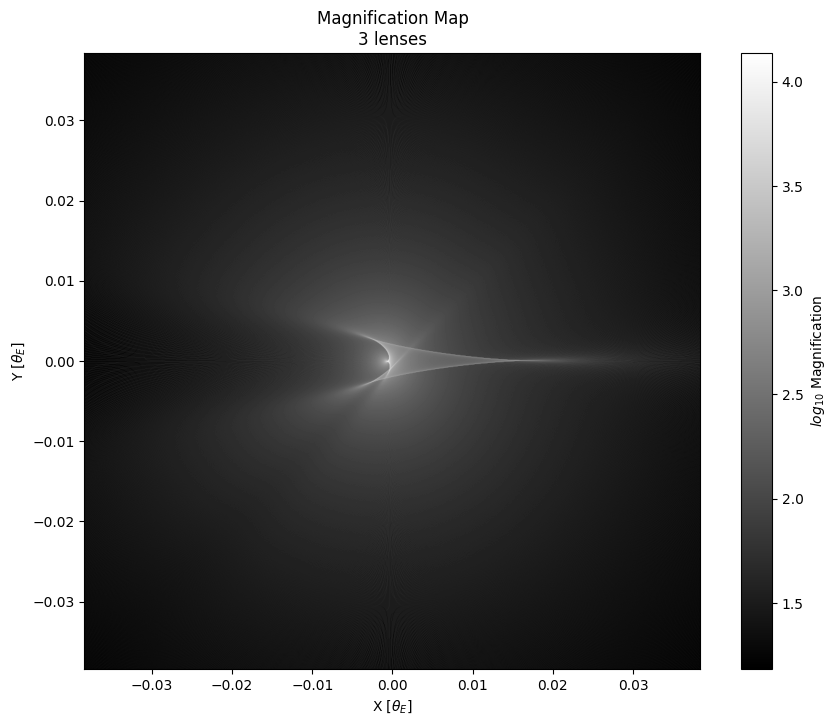

In [23]:
sim = IRSC.IRSCaustics(annulus_param_dict=triple_lens_parameters)
series_magnifications = sim.series_calculate()
sim.plot()

---------------------
Total time: 5.837 seconds
Plotting magnification map: 0.02 seconds


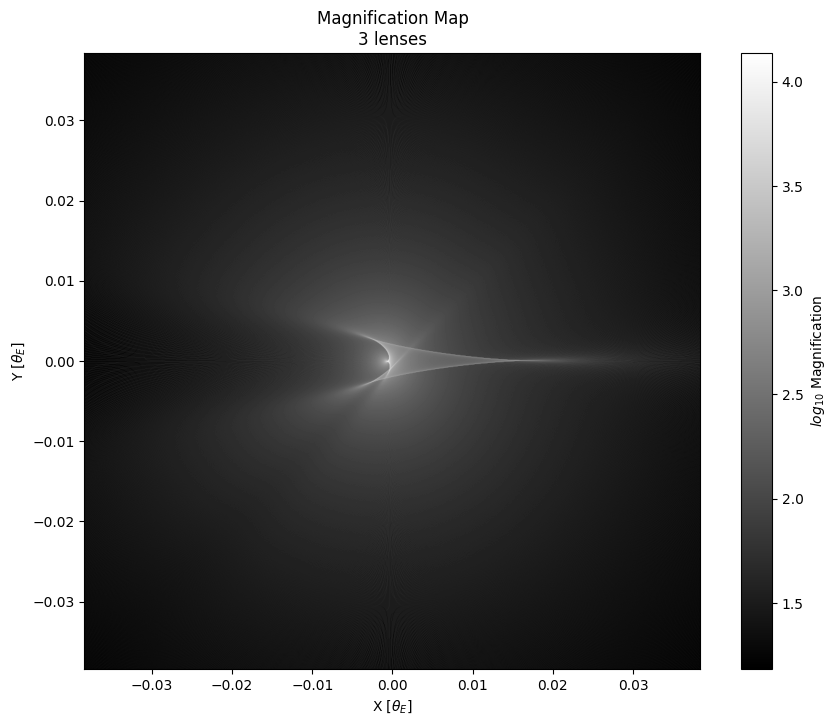

In [38]:
sim = IRSC.IRSCaustics(annulus_param_dict=triple_lens_parameters)
parallel_magnifications = sim.parallel_calculate(cpus=4)
sim.plot()

In [29]:
print((series_magnifications == parallel_magnifications).all())

True
